# T63 — Reconstructing plant-fossil occurrences and Early Triassic super-greenhouse climate

**Cluster J: Paleoclimate.**  *Author-contributed by:* Zhen Xu (China University of Geosciences, Wuhan / University of Leeds, UK) and Benjamin J.W. Mills (University of Leeds, UK).

*Based on:* Xu, Z., Yu, J., Yin, H., Merdith, A.S., Hilton, J., Allen, B.J., Gurung, K., Wignall, P.B., Dunhill, A.M., Shen, J., Schwartzman, D., Goddéris, Y., Donnadieu, Y., Wang, Y., Zhang, Y., Poulton, S.W. & Mills, B.J.W. (2025). *Early Triassic super-greenhouse climate driven by vegetation collapse.* **Nature Communications** 16, 5400. https://doi.org/10.1038/s41467-025-60396-y

The Permian–Triassic Mass Extinction (PTME, \~252 Ma) was followed by \~5 Myr of super-greenhouse conditions that persisted long after the Siberian Traps volcanism that triggered the crisis had waned. The source study argues that collapse of terrestrial vegetation — especially in the tropics — removed a major carbon-sequestration and silicate-weathering sink, letting volcanogenic CO₂ linger in the atmosphere for millions of years rather than being drawn down on the usual \~100 kyr weathering timescale. This notebook reconstructs the plant-fossil occurrence evidence behind that argument — classified into ecologically-meaningful **Plant Functional Types (PFTs)** — into palaeogeographic coordinates for two time-slices spanning the boundary, and overlays them on the paper's Earth-system-model air-temperature fields for direct model-data comparison.

Fossil plant occurrences are prone to taxonomic over-splitting: different organ fragments of the same plant (leaves, seeds, wood, pollen) are often described under separate morphological names, artificially inflating apparent diversity. The occurrences bundled here have already been normalised to remove this duplication, following the procedures in Xu et al. (2022, *Earth-Science Reviews*) and Xu et al. (2025, *Palaeogeography, Palaeoclimatology, Palaeoecology*) — see Sources below.

**A scope note from the contributing authors**: the PFT classification used here was built specifically for Permian–Triassic vegetation and should be applied cautiously, if at all, to fossil assemblages from other geologic intervals. The reconstruction-and-overlay *workflow* itself, however, is general — it applies just as well to animal fossils, geochemical sampling sites, or any other occurrence-based dataset.

## What this notebook produces

1. **§1–§3 — Load, reconstruct, and export palaeo-positioned plant-fossil occurrences.** Two PFT-classified occurrence datasets — Changhsingian (latest Permian, 252 Ma, 138 occurrences) and Induan (earliest Triassic, 251 Ma, 102 occurrences) — are each reconstructed from present-day to their own stage age using GPlately and the Scotese (2016) plate model, then exported with palaeo-coordinates attached.
2. **§4–§6 — Classify occurrences into Plant Functional Types and prepare the shared map furniture.** Defines the 7-class PFT colour scheme, generates reconstructed coastlines for both stages, and writes a pyGMT categorical legend spec.
3. **§7 — Overlay reconstructed PFT occurrences on Early Triassic air-temperature model fields.** A two-panel paleogeographic figure (Changhsingian above, Induan below) with reconstructed coastlines, air-temperature grids, and PFT-coded fossil occurrences under a shared legend and colour bar — directly comparable to the source paper's headline model-data figure.

## Learning objectives

- Reconstruct fossil-occurrence coordinates to their own stage-specific palaeo-position via `gplately.Points.reconstruct`, using the Scotese (2016) plate model through `gplately.DataServer`.
- Classify an occurrence dataset into ecologically-meaningful climate-sensitive categories (Plant Functional Types) and render them as a pyGMT categorical point legend.
- Overlay reconstructed point data on a gridded palaeoclimate-model field (`fig.grdimage` + `fig.plot`) with a shared multi-panel legend and colour bar spanning two stacked pyGMT panels.
- Build a pyGMT `.txt` legend spec file programmatically from a Python style dictionary, rather than hand-writing one.

## Prerequisites and runtime

- **Plate model**: Scotese (2016), fetched via `gplately.DataServer("Scotese2016")` on first run.
- **Data (bundled)** at `data/paleo_plant_climate/` (\~60 KB total): `Changhsingian_occurrences.csv` (138 rows) and `Induan_occurrences.csv` (102 rows), each with present-day coordinates + PFT code; `clima_lon_shifted.csv` / `clima_lat.csv` (48 / 40 grid-coordinate vectors) and `P_Tair_shifted.csv` / `T_Tair_shifted.csv` (40×48 air-temperature fields, °C) for the Changhsingian and Induan stages respectively.
- **Python**: `gplately`, `pygplates`, `pygmt`, `pandas`, `numpy`, `xarray`.
- **Runtime**: \~20 s (dominated by the first-run Scotese 2016 model download).


## Environment + imports

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent -- only runs if `../data` exists and `./data`
# doesn't.
import os
from pathlib import Path
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

# Standard scientific Python packages
import numpy as np
import pandas as pd
import xarray as xr

# GPlately
import gplately
from gplately import pygplates
from gplately import DataServer

# PyGMT
import pygmt

# Utilities
from IPython.display import display, HTML

print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pandas {pd.__version__}  numpy {np.__version__}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pandas 2.2.3  numpy 2.3.2


## 1. Load fossil occurrence data

In [2]:
# ---------------------------------------------------------------
# Read Changhsingian (latest Permian, 252 Ma) and Induan (earliest
# Triassic, 251 Ma) occurrences, each pre-classified into a Plant
# Functional Type (PFT) code -- see §4.
# ---------------------------------------------------------------

changhsingian_occurrences = pd.read_csv("data/paleo_plant_climate/Changhsingian_occurrences.csv")
induan_occurrences = pd.read_csv("data/paleo_plant_climate/Induan_occurrences.csv")

print("=" * 60)
print(f"Changhsingian occurrences: {len(changhsingian_occurrences)}")
display(changhsingian_occurrences.head())
print("\nFunctional types:")
display(changhsingian_occurrences["Function"].value_counts())

print("\n" + "=" * 60)
print(f"Induan occurrences: {len(induan_occurrences)}")
display(induan_occurrences.head())
print("\nFunctional types:")
display(induan_occurrences["Function"].value_counts())


Changhsingian occurrences: 138


,ID,Country,Area,Function,Lng,Lat,Environment
0,1,Austria,NaN,5,13.65,47.53,Terrestrial
1,2,Australia,Queensland,7,147.30,-24.70,Terrestrial
2,3,Australia,Queensland,7,148.00,-25.00,Terrestrial
3,4,Australia,Queensland,7,148.80,-23.30,Terrestrial
4,5,Australia,Queensland,7,142.70,-20.92,Terrestrial



Functional types:


Function
1    43
4    40
7    27
5    22
3     6
Name: count, dtype: int64


Induan occurrences: 102


,ID,Country,Area,Function,Lng,Lat,Environment
0,1,Australia,Queensland,6,148.00,-24.83,Terrestrial
1,2,Australia,Queensland,6,148.90,-23.64,Terrestrial
2,3,North China,NorthChina,6,109.19,35.39,Terrestrial
3,4,Xinjiang,Xinjiang,6,88.80,43.95,Terrestrial
4,5,North China,NorthChina,5,111.20,36.40,Terrestrial



Functional types:


Function
6    41
5    34
3    27
Name: count, dtype: int64

## 2. Reconstruct modern coordinates into palaeocoordinates

In [3]:
# Download the Scotese (2016) plate reconstruction model
data_server = DataServer("Scotese2016")

rotation_model, topology_features, static_polygons = (
    data_server.get_plate_reconstruction_files()
)
coastlines, continents, COBs = data_server.get_topology_geometries()

plate_model = gplately.PlateReconstruction(
    rotation_model,
    topology_features,
    static_polygons,
)

# ---------------------------------------------------------------
# Changhsingian (252 Ma)
# ---------------------------------------------------------------
changhsingian_time = 252

changhsingian_points = gplately.Points(
    plate_model,
    changhsingian_occurrences["Lng"],
    changhsingian_occurrences["Lat"],
)
changhsingian_palaeo_lon, changhsingian_palaeo_lat = changhsingian_points.reconstruct(
    changhsingian_time, return_array=True,
)

# ---------------------------------------------------------------
# Induan (251 Ma)
# ---------------------------------------------------------------
induan_time = 251

induan_points = gplately.Points(
    plate_model,
    induan_occurrences["Lng"],
    induan_occurrences["Lat"],
)
induan_palaeo_lon, induan_palaeo_lat = induan_points.reconstruct(
    induan_time, return_array=True,
)


## 3. Add palaeocoordinates to the dataset

In [4]:
# ---------------------------------------------------------------
# Changhsingian
# ---------------------------------------------------------------
changhsingian_occurrences["PalaeoLng"] = changhsingian_palaeo_lon
changhsingian_occurrences["PalaeoLat"] = changhsingian_palaeo_lat

display(changhsingian_occurrences[["Lat", "Lng", "PalaeoLat", "PalaeoLng"]].head())

changhsingian_output_file = "Changhsingian_occurrences_reconstructed.csv"
changhsingian_occurrences.to_csv(changhsingian_output_file, index=False)
print(f"Saved Changhsingian reconstructed data to:\n{changhsingian_output_file}")

# ---------------------------------------------------------------
# Induan
# ---------------------------------------------------------------
induan_occurrences["PalaeoLng"] = induan_palaeo_lon
induan_occurrences["PalaeoLat"] = induan_palaeo_lat

display(induan_occurrences[["Lat", "Lng", "PalaeoLat", "PalaeoLng"]].head())

induan_output_file = "Induan_occurrences_reconstructed.csv"
induan_occurrences.to_csv(induan_output_file, index=False)
print(f"\nSaved Induan reconstructed data to:\n{induan_output_file}")


,Lat,Lng,PalaeoLat,PalaeoLng
0,47.53,13.65,4.955534,27.489848
1,-24.70,147.30,-58.586757,136.793112
2,-25.00,148.00,-58.889833,138.014312
3,-23.30,148.80,-57.183358,139.364788
4,-20.92,142.70,-54.596602,129.437311


Saved Changhsingian reconstructed data to:
Changhsingian_occurrences_reconstructed.csv


,Lat,Lng,PalaeoLat,PalaeoLng
0,-24.83,148.00,-58.186378,137.120846
1,-23.64,148.90,-56.999657,138.661224
2,35.39,109.19,31.390593,88.264465
3,43.95,88.80,45.003546,72.762195
4,36.40,111.20,31.903366,90.433129



Saved Induan reconstructed data to:
Induan_occurrences_reconstructed.csv


## 4. Define Plant Functional Types (PFTs)

The Plant Functional Types (PFTs) used here are based on fossil vegetation ecology rather than the modern Köppen–Geiger climate classification. Similar names are adopted only to facilitate interpretation -- see the scope note above.

In [5]:
PLANT_FUNCTIONAL_TYPES = {
    1: {"name": "Tropical Evergreen Rainforest", "colour": "#0B5D1E"},
    2: {"name": "Tropical Seasonal Forest",      "colour": "#7BC96F"},
    3: {"name": "Temperate everwet",             "colour": "#084594"},
    4: {"name": "Temperate seasonal",            "colour": "#6BAED6"},
    5: {"name": "Savanna seasonal",              "colour": "#E66101"},
    6: {"name": "Savanna arid",                  "colour": "#FDD835"},
    7: {"name": "Boreal",                        "colour": "#9966CC"},
}


## 5. Generate reconstructed coastlines

In [6]:
# ---------------------------------------------------------------
# Changhsingian (252 Ma)
# ---------------------------------------------------------------
changhsingian_gplot = gplately.PlotTopologies(
    plate_reconstruction=plate_model,
    coastlines=coastlines,
    time=float(changhsingian_time),
)
changhsingian_coast_gdf = changhsingian_gplot.get_coastlines()
print(f"Changhsingian: {len(changhsingian_coast_gdf)} coastline features")

# ---------------------------------------------------------------
# Induan (251 Ma)
# ---------------------------------------------------------------
induan_gplot = gplately.PlotTopologies(
    plate_reconstruction=plate_model,
    coastlines=coastlines,
    time=float(induan_time),
)
induan_coast_gdf = induan_gplot.get_coastlines()
print(f"Induan: {len(induan_coast_gdf)} coastline features")


Changhsingian: 1370 coastline features
Induan: 1370 coastline features


## 6. Create legend file

In [7]:
from pathlib import Path

legend_file = Path("plant_legend.txt")

with open(legend_file, "w") as f:
    # Title
    f.write("H 18p Helvetica-Bold Plant Functional Types\n")
    f.write("G 0.2c\n")
    f.write("D 0.4c 1p\n")
    f.write("G 0.2c\n")

    # Entries
    for _, style in PLANT_FUNCTIONAL_TYPES.items():
        f.write(f"S 0.60c c 0.45c {style['colour']} 0.6p 1.0c {style['name']}\n")


## 7. Plot reconstructed fossil occurrences on Scotese (2016) palaeogeographic maps, with air temperature underneath

/opt/miniconda3/lib/python3.12/site-packages/pygmt/clib/session.py:1648: RuntimeWarning: Grid may have irregular spacing in the 'lat' dimension, but GMT only supports regular spacing. Calculated regular spacing 4.4409230769230765 is assumed in the 'lat' dimension.
/opt/miniconda3/lib/python3.12/site-packages/pygmt/clib/session.py:1648: RuntimeWarning: Grid may have irregular spacing in the 'lat' dimension, but GMT only supports regular spacing. Calculated regular spacing 4.4409230769230765 is assumed in the 'lat' dimension.


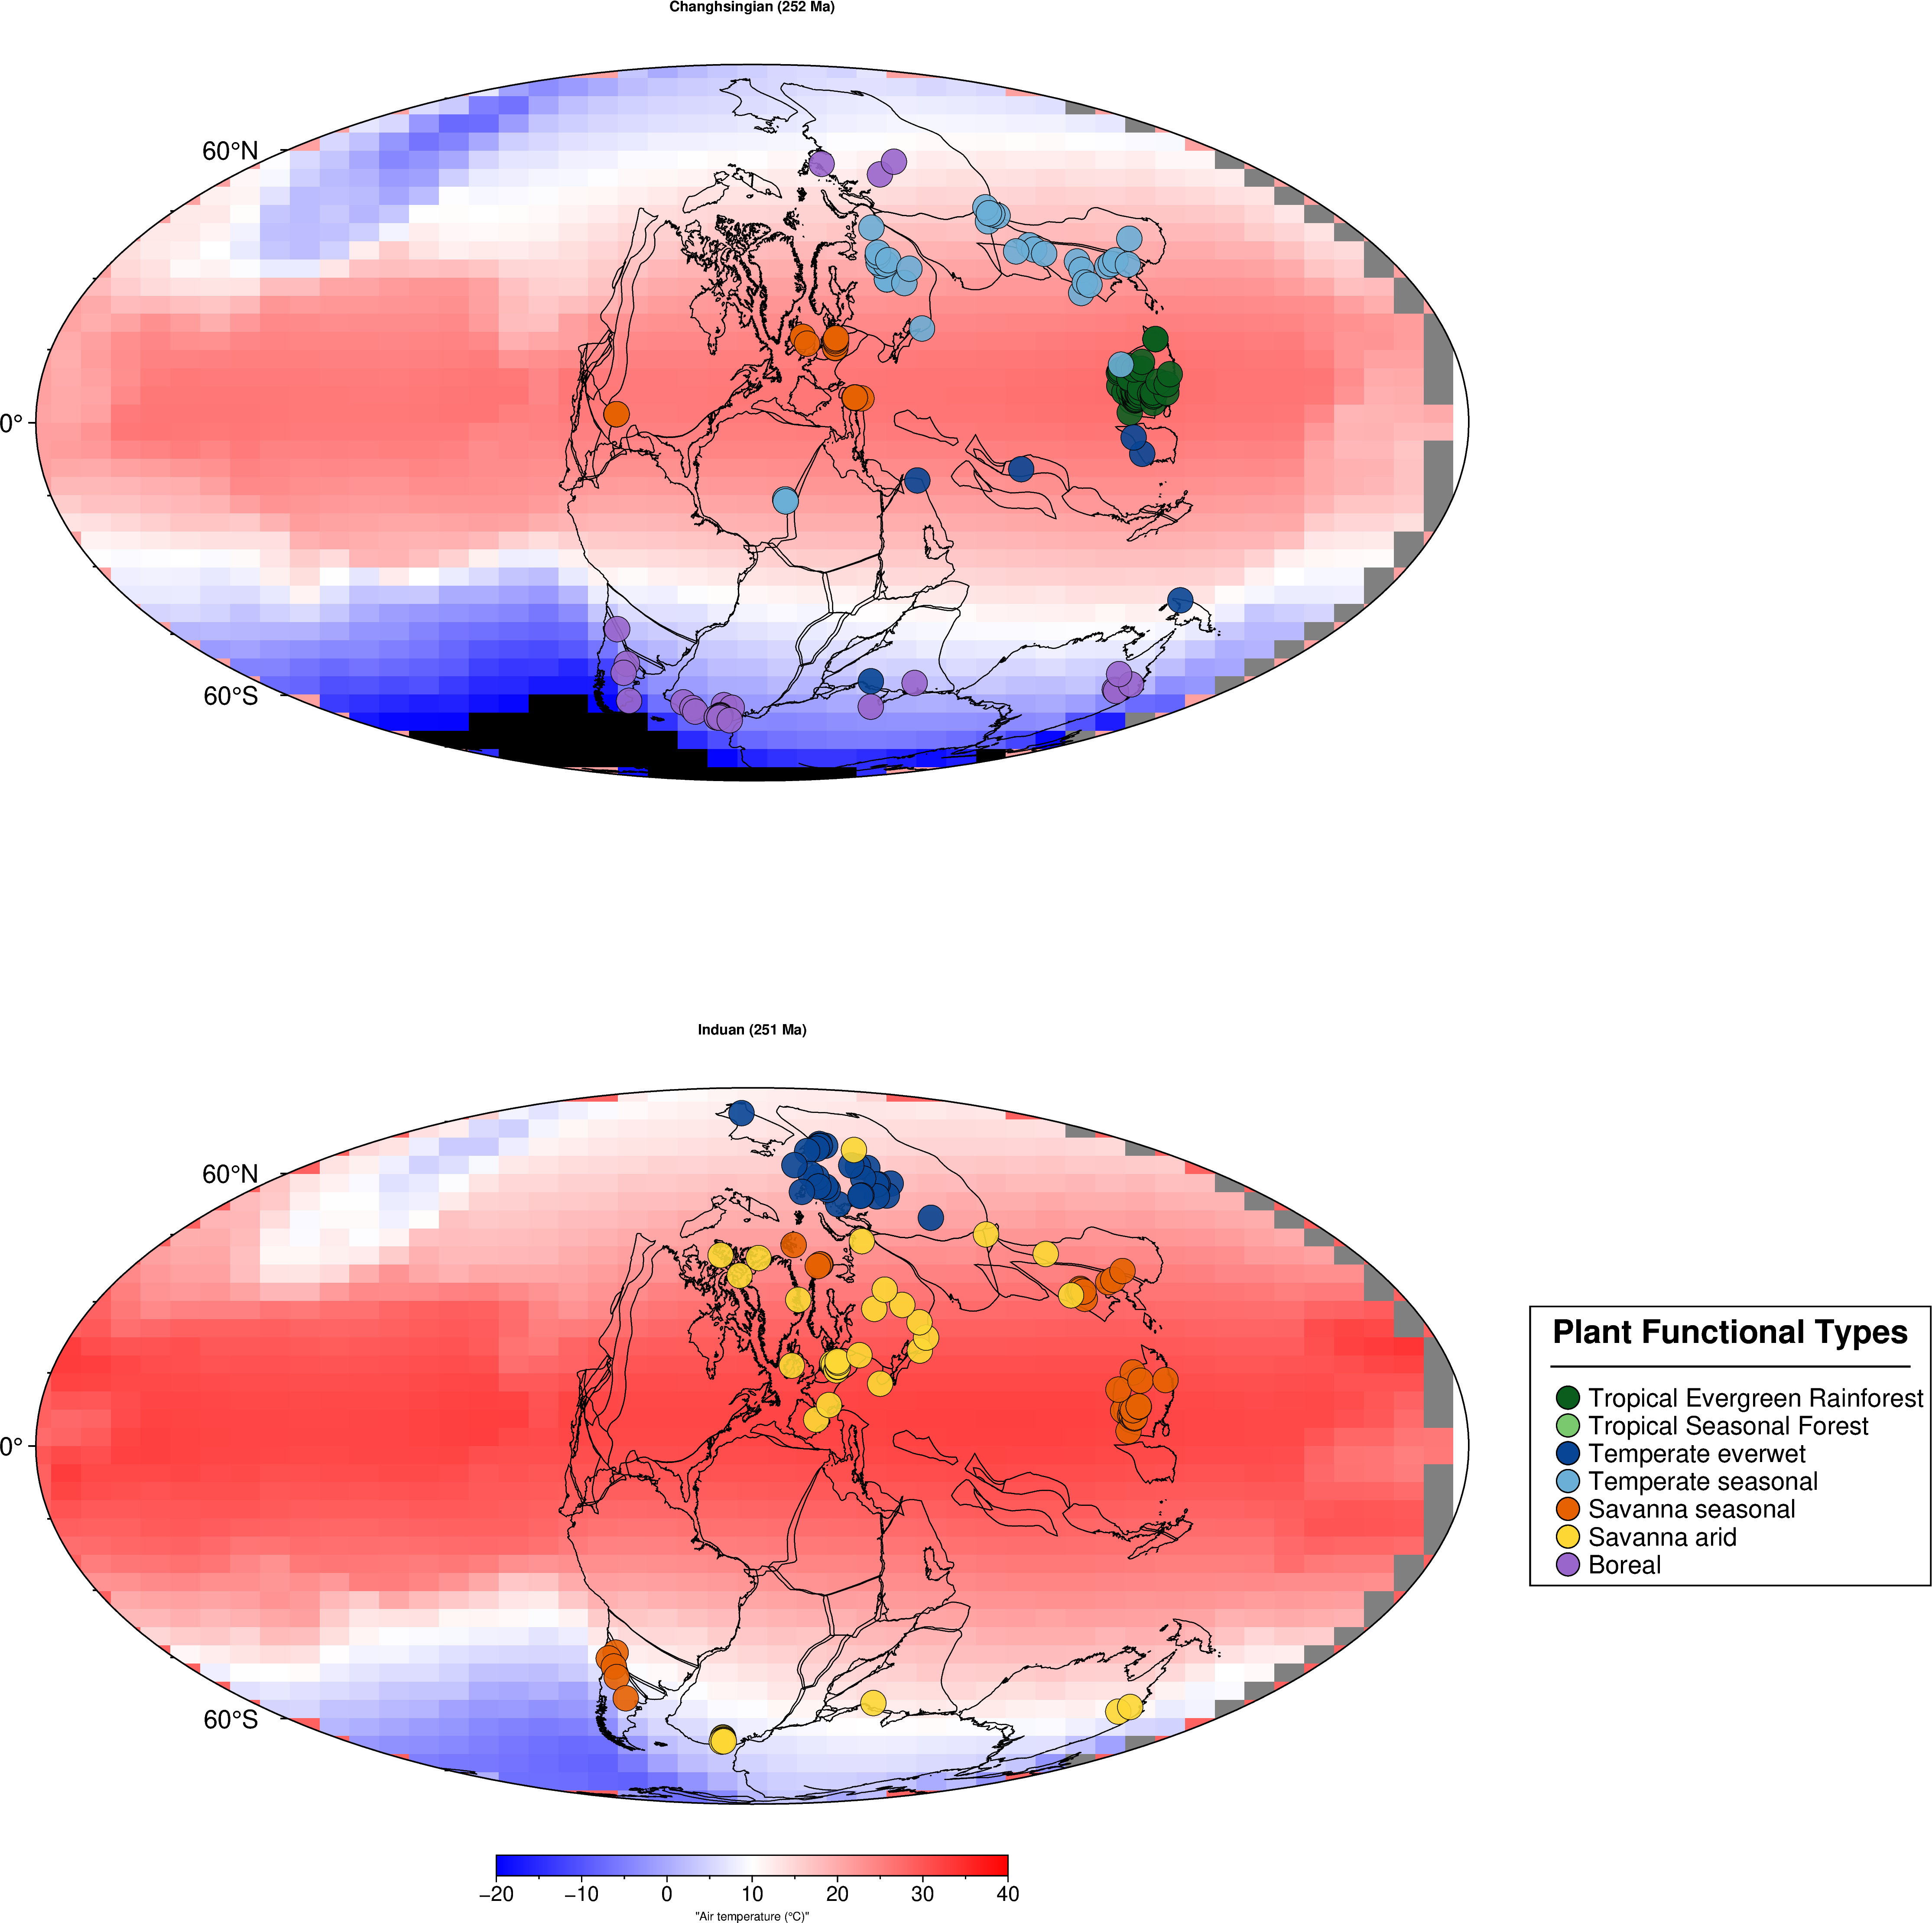

In [8]:
fig = pygmt.Figure()
pygmt.config(MAP_GRID_PEN_PRIMARY="0.25p,gray70", FONT_ANNOT_PRIMARY="14p,Helvetica")

engine = gplately.PygmtPlotEngine()

# ================================================================
# Air temperature grids
# ================================================================
lon = pd.read_csv("data/paleo_plant_climate/clima_lon_shifted.csv", header=None, encoding="utf-8-sig").to_numpy().squeeze()
lat = pd.read_csv("data/paleo_plant_climate/clima_lat.csv", header=None, encoding="utf-8-sig").to_numpy().squeeze()
Tair_P = pd.read_csv("data/paleo_plant_climate/P_Tair_shifted.csv", header=None, encoding="utf-8-sig").to_numpy()
Tair_T = pd.read_csv("data/paleo_plant_climate/T_Tair_shifted.csv", header=None, encoding="utf-8-sig").to_numpy()

changhsingian_temperature_grid = xr.DataArray(
    Tair_P, coords={"lat": lat, "lon": lon}, dims=("lat", "lon"),
).sortby(["lat", "lon"])
induan_temperature_grid = xr.DataArray(
    Tair_T, coords={"lat": lat, "lon": lon}, dims=("lat", "lon"),
).sortby(["lat", "lon"])

# Temperature colour palette
pygmt.makecpt(cmap="polar", series=[-20, 40, 1], continuous=True)

# Geological stages
stages = [
    {"name": "Changhsingian", "time": changhsingian_time, "occurrences": changhsingian_occurrences,
     "coast": changhsingian_coast_gdf, "temperature_grid": changhsingian_temperature_grid},
    {"name": "Induan", "time": induan_time, "occurrences": induan_occurrences,
     "coast": induan_coast_gdf, "temperature_grid": induan_temperature_grid},
]

def plot_stage(fig, stage):
    # Air temperature
    fig.grdimage(grid=stage["temperature_grid"], region="d", projection="W0/22c", cmap=True)
    fig.basemap(region="d", projection="W0/22c",
                frame=["af", f'+t{stage["name"]} ({stage["time"]} Ma)'])

    # Coastlines
    engine.plot_geo_data_frame(fig, stage["coast"], pen="0.5p,black")

    # Fossil occurrences, coloured by PFT
    for pft, style in PLANT_FUNCTIONAL_TYPES.items():
        subset = stage["occurrences"][stage["occurrences"]["Function"] == pft]
        if subset.empty:
            continue
        fig.plot(x=subset["PalaeoLng"].to_numpy(), y=subset["PalaeoLat"].to_numpy(),
                  style="c0.50c", fill=style["colour"], pen="0.25p,black", transparency=10)


# Changhsingian
plot_stage(fig, stages[0])

# Induan
fig.shift_origin(yshift="-16c")
plot_stage(fig, stages[1])

# Shared legend
fig.legend(spec=str(legend_file), position="JMR+jML+o1.2c/0c", box="+gwhite+p0.8p")

# Shared temperature colour bar
fig.colorbar(cmap=True, position="JBC+jBC+o0c/-1.4c+w10c/0.4c+h",
             frame='xa10f5+l"Air temperature (°C)"')

fig.show(width=1100)


### How to read the map

- **Panel colour (background)** — modelled air temperature (°C) for each stage, draped over the reconstructed coastlines.
- **Panel dots (foreground)** — plant-fossil occurrences reconstructed to their own stage's palaeo-position, coloured by Plant Functional Type (PFT).
- **Changhsingian → Induan** — across the Permian-Triassic boundary, PFT composition shifts markedly toward more arid-tolerant, seasonal, and boreal-affinity types (savanna/boreal codes 5-7), consistent with tropical vegetation collapse and a contraction of everwet/rainforest floras (codes 1-3) -- the biological signature behind the source paper's super-greenhouse argument.
- **Watch for** whether the warmest modelled air-temperature regions coincide with the occurrences classified as arid/savanna types, and whether cooler higher-latitude cells still host any tropical-affinity PFTs (a mismatch worth flagging as either model or classification uncertainty).


## Extend this

- **Apply the workflow to a different occurrence type.** Nothing here is plant-specific except the PFT dictionary in §4 -- the same load → reconstruct → classify → overlay pattern works unchanged for animal fossils, geochemical sample sites, or any other occurrence-based dataset with present-day coordinates and an age.
- **Swap the plate model.** Change `DataServer("Scotese2016")` to `DataServer("Merdith2021")` or `Muller2022` (any paleomag-frame model) to test how much the PFT-vs-temperature spatial pattern depends on the choice of absolute reference frame -- see T35 and T68 for the frame-uncertainty argument this would be testing.
- **Add more stages.** The source paper's supplementary archive covers additional Permian-Triassic substages beyond the Changhsingian/Induan pair bundled here; the notebook's two-stage loop pattern extends directly to a longer stage list.
- **Caution on the PFT scheme.** As noted above, this 7-class PFT classification was built specifically for Permian-Triassic vegetation. Applying it to other geologic intervals without revisiting the classification criteria would misrepresent the underlying floras.

## Related notebooks

- **T62** -- Boucot climate-sensitive lithologies: the cluster's other biological/lithological climate-proxy notebook -- lithology-coded rather than fossil-plant-coded, but the same climate-sensitive-point-data-on-a-reconstructed-map idea.
- **T64** -- Deep-time paleoclimate-model snapshots: renders the same 252 Ma end-Permian PLASIM-GENIE hothouse snapshot as a pure model field, without the fossil-proxy overlay this notebook adds.
- **T60 / T61** -- PBDB paleobiogeography / H3 bioregionalisation: the same per-occurrence reconstruct-to-palaeo-position pattern, applied to animal-fossil biogeography rather than plant-climate proxies.

## Sources

- Xu, Z., Yu, J., Yin, H., Merdith, A.S., Hilton, J., Allen, B.J., Gurung, K., Wignall, P.B., Dunhill, A.M., Shen, J., Schwartzman, D., Goddéris, Y., Donnadieu, Y., Wang, Y., Zhang, Y., Poulton, S.W. & Mills, B.J.W. (2025). Early Triassic super-greenhouse climate driven by vegetation collapse. *Nature Communications* 16, 5400. https://doi.org/10.1038/s41467-025-60396-y
- Xu, Z., Hilton, J., Yu, J., Wignall, P.B., Yin, H., Xue, Q., Ran, W., Li, H., Shen, J. & Meng, F. (2022). End Permian to Middle Triassic plant species richness and abundance patterns in South China: Coevolution of plants and the environment through the Permian-Triassic transition. *Earth-Science Reviews* 232, 104136. https://doi.org/10.1016/j.earscirev.2022.104136
- Xu, Z., Bateson, E., Cleal, C.J., Hutton, R., Yu, J., Wang, S.-J., Knoll, A.H., Mills, B.J.W. & Hilton, J. (2025). Normalization of fossil plant megafossil databases for diversity and palaeobiogeography analyses by filtering taxonomic duplication: Principles, methods, examples, and recommendations. *Palaeogeography, Palaeoclimatology, Palaeoecology* 678, 113236. https://doi.org/10.1016/j.palaeo.2025.113236
- Scotese, C.R. (2016). PALEOMAP PaleoAtlas for GPlates and the PaleoData Plotter Program, PALEOMAP Project. https://www.earthbyte.org/paleomap-paleoatlas-for-gplates/
- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3-10.
